In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, '..')

# 04 — Overfitting & Underfitting
Demonstrate bias-variance tradeoff via learning curves.

**Total Error = Bias² + Variance + Irreducible Noise**

- **Underfitting (high bias):** Strong L2 regularization (C=0.0001) + only top-5 features
- **Overfitting (high variance):** Degree-2 polynomial features + no regularization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from src.data_loader import load_uci_seizure
from src.preprocessing import build_pipeline_a
from src.models import make_baseline, make_underfit
from src.evaluation import cross_val_evaluate, summarize_cv_results, plot_learning_curve
from src.utils import RANDOM_STATE

X_uci, y_uci = load_uci_seizure()
X_main, X_test, y_main, y_test = train_test_split(
    X_uci, y_uci, test_size=0.2, stratify=y_uci, random_state=RANDOM_STATE)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [3]:
# Baseline learning curve
plot_learning_curve(
    build_pipeline_a(k=20), make_baseline(), X_main, y_main,
    title='Learning Curve — Baseline (no regularization, k=20)',
    save_path='../results/figures/learning_curve_baseline.png'
)
print('Baseline learning curve saved.')

Baseline learning curve saved.


In [4]:
# Underfitting learning curve
plot_learning_curve(
    build_pipeline_a(k=5), make_underfit(), X_main, y_main,
    title='Learning Curve — Underfitting (C=0.0001, k=5)',
    save_path='../results/figures/learning_curve_underfit.png'
)
print('Underfitting learning curve saved.')

Underfitting learning curve saved.


In [5]:
# Overfitting: polynomial degree-2 features + no regularization
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(mutual_info_classif, k=20)),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
])
overfit_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000, random_state=RANDOM_STATE)
overfit_results = cross_val_evaluate(poly_pipe, overfit_model, X_main, y_main, CV)
baseline_results = cross_val_evaluate(build_pipeline_a(k=20), make_baseline(), X_main, y_main, CV)

print(f"Baseline  PR-AUC: {baseline_results['pr_auc'].mean():.3f} ± {baseline_results['pr_auc'].std():.3f}")
print(f"Overfit   PR-AUC: {overfit_results['pr_auc'].mean():.3f} ± {overfit_results['pr_auc'].std():.3f}")
print(f"Underfit  PR-AUC: {cross_val_evaluate(build_pipeline_a(k=5), make_underfit(), X_main, y_main, CV)['pr_auc'].mean():.3f}")

c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal

Baseline  PR-AUC: 0.478 ± 0.018
Overfit   PR-AUC: 0.929 ± 0.011


c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal

Underfit  PR-AUC: 0.487


c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal

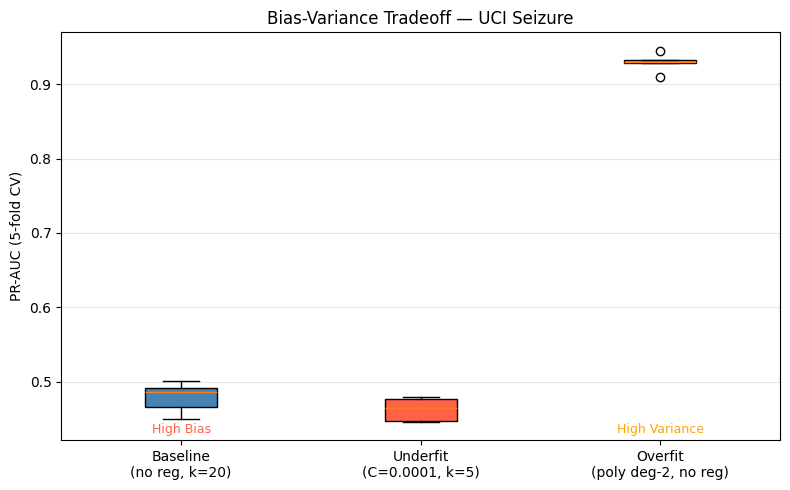

In [6]:
# Bias-variance summary plot: PR-AUC distribution across folds
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Baseline\n(no reg, k=20)', 'Underfit\n(C=0.0001, k=5)', 'Overfit\n(poly deg-2, no reg)']
data = [baseline_results['pr_auc'], 
        cross_val_evaluate(build_pipeline_a(k=5), make_underfit(), X_main, y_main, CV)['pr_auc'],
        overfit_results['pr_auc']]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
colors = ['steelblue', 'tomato', 'orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('PR-AUC (5-fold CV)')
ax.set_title('Bias-Variance Tradeoff — UCI Seizure')
ax.grid(True, alpha=0.3, axis='y')

# Annotate bias/variance regions
ax.text(1, ax.get_ylim()[0] + 0.01, 'High Bias', ha='center', color='tomato', fontsize=9)
ax.text(3, ax.get_ylim()[0] + 0.01, 'High Variance', ha='center', color='orange', fontsize=9)
plt.tight_layout()
plt.savefig('../results/figures/bias_variance_boxplot.png', dpi=150)
plt.show()

In [ ]:
# Regularization strength vs PR-AUC (C sweep) — shows bias-variance tradeoff curve
from src.models import make_regularized

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores, val_scores = [], []

for C in C_values:
    model = make_regularized('L2', C)
    pipe = build_pipeline_a(k=20)
    results = cross_val_evaluate(pipe, model, X_main, y_main, CV)
    val_scores.append(results['pr_auc'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, val_scores, marker='o', color='steelblue', label='Val PR-AUC (L2)')
ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='C=1 (selected)')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('PR-AUC')
ax.set_title('Regularization Strength vs Validation PR-AUC (UCI Seizure, Pipeline A)')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate regions
ax.annotate('High Bias\n(underfitting)', xy=(0.001, val_scores[0]), xytext=(0.003, val_scores[0]-0.05),
            arrowprops=dict(arrowstyle='->', color='tomato'), color='tomato', fontsize=8)
ax.annotate('High Variance\n(overfitting)', xy=(100, val_scores[-1]), xytext=(20, val_scores[-1]-0.05),
            arrowprops=dict(arrowstyle='->', color='orange'), color='orange', fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/reg_strength_curve.png', dpi=150)
plt.show()

c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penal